In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = "Arial"
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

KeyError: 'eps.fonttype is not a valid rc parameter (see rcParams.keys() for a list of valid parameters)'

In [2]:
audio_tensors = torch.load("tensors/tensors_audio.pt")
Q, C, L = audio_tensors["q"], audio_tensors["c"], audio_tensors["l"]

In [3]:
idx = 0
q, l = Q[idx], L[idx]
c = C[torch.where(l == 1)[0]][0]
qct = q @ c.T
truelocs = [i.argmax().item() for i in qct]

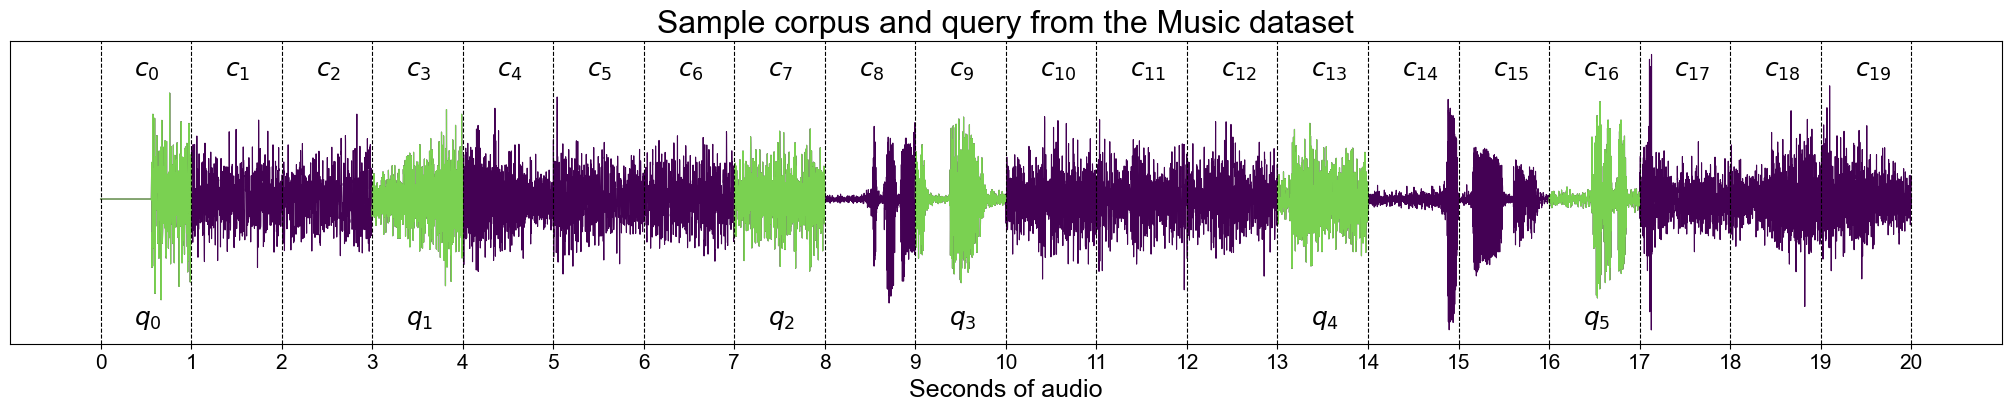

: 

In [7]:
err_markersize = 10
parseq_markersize = 250
parseq_idmarkersize = 200
axis_fontsize = 18
title_fontsize = 23
label_fontsize = 15

c = c.clamp(c.min(), 0.1)
cflat = c.reshape(-1)
step = 5

colors = plt.cm.viridis(np.linspace(0, 0.8, 2, endpoint=True))

fig = plt.figure(figsize=(20, 4), constrained_layout=True)
# fig.constrained_layout()
plt.plot(cflat[::step], linewidth=0.8, color=colors[0])
np.random.seed(19)
locs = np.random.choice(range(20), 6, replace=False)
locs = sorted(locs)

plt.tick_params(axis='both', which='major', labelsize=label_fontsize)

n = 0
for loc in locs:
    x = range(loc*4000//step, (loc+1)*4000//step)
    y = c[loc].reshape(-1)[::step]
    plt.plot(x, y, color=colors[-1], linestyle="-", linewidth=0.8)
    plt.text(x[1500//step], c.min()+2e-2, r"$q_{}$".format(n), fontsize=axis_fontsize)
    n += 1

n = 0
for i in range(21):
    x = range(i*4000//step, (i+1)*4000//step)
    plt.axvline(i*4000//step, color="black", linestyle="--", linewidth=0.8)
    if n < 20:
        st = f"c_{n}"
        plt.text(x[1500//step], c.max()-1.5e-2, r"$c_{%d}$" %n, fontsize=axis_fontsize)
    n += 1


plt.yticks([])
plt.xlabel("Seconds of audio", fontsize=axis_fontsize)
plt.xticks([4000//step*i for i in range(21)], [str(i) for i in range(21)])
plt.title("Sample corpus and query from the Music dataset", fontsize=title_fontsize)
plt.savefig("../parseq_figs/sample_qc.pdf")
plt.show()